# Proyecto Sprint 13: Predicción de Churn de Clientes - Model Fitness

## Descripción del Proyecto

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

**Objetivos:**
1. Predecir la probabilidad de pérdida (para el próximo mes) para cada cliente
2. Elaborar retratos de usuarios típicos: seleccionar los grupos más destacados y describir sus características principales
3. Analizar los factores que más impactan la pérdida
4. Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente



## Paso 1: Carga de Datos

Cargamos el dataset con información sobre cancelación de clientes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
df = pd.read_csv('datasets/gym_churn_us.csv')

# Información básica
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()


Dimensiones del dataset: (4000, 14)

Primeras filas:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [2]:
# Información sobre columnas y tipos de datos
print("Información del dataset:")
df.info()
print("\nColumnas:", df.columns.tolist())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total      

## Paso 2: Análisis Exploratorio de Datos (EDA)


### 2.1 Valores Ausentes


In [3]:
# Verificar valores ausentes
print("Valores ausentes por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")


Valores ausentes por columna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Total de valores ausentes: 0


### 2.2 Estadísticas Descriptivas


In [4]:
# Estadísticas descriptivas
df.describe()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### 2.3 Comparación de Medias: Churn vs No Churn


In [5]:
# Comparación de valores medios por grupo de cancelación
churn_comparison = df.groupby('Churn').mean()
print("Valores medios por grupo de cancelación:")
churn_comparison


Valores medios por grupo de cancelación:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


In [6]:
# Distribución de Churn
print("Distribución de cancelación:")
print(df['Churn'].value_counts())
print(f"\nPorcentaje de cancelación: {df['Churn'].mean()*100:.2f}%")


Distribución de cancelación:
Churn
0    2939
1    1061
Name: count, dtype: int64

Porcentaje de cancelación: 26.52%


### 2.4 Histogramas y Distribuciones por Grupo de Cancelación


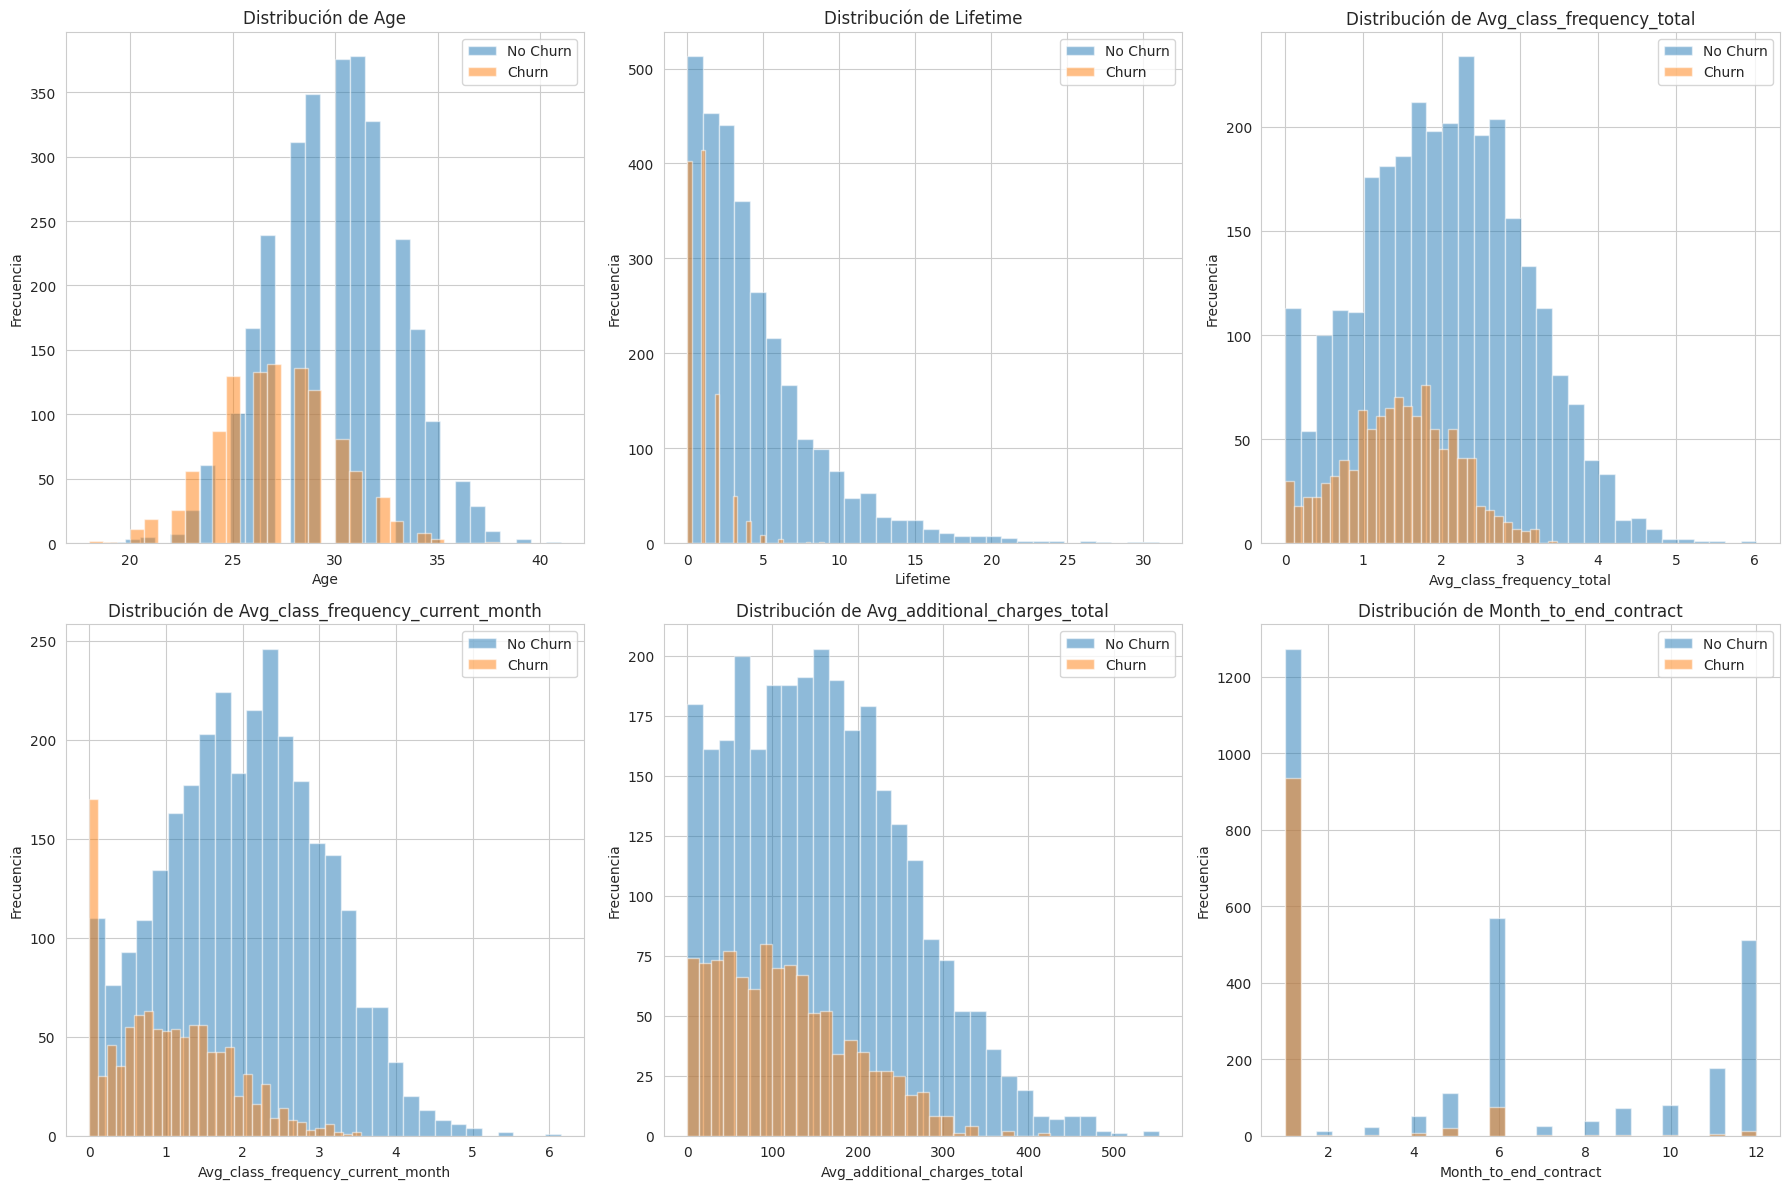

In [7]:
# Seleccionar columnas numéricas para visualización
numeric_cols = ['Age', 'Lifetime', 'Avg_class_frequency_total', 
                'Avg_class_frequency_current_month', 'Avg_additional_charges_total',
                'Month_to_end_contract']

# Crear histogramas comparativos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df[df['Churn'] == 0][col].hist(alpha=0.5, label='No Churn', bins=30, ax=axes[idx])
    df[df['Churn'] == 1][col].hist(alpha=0.5, label='Churn', bins=30, ax=axes[idx])
    axes[idx].set_title(f'Distribución de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()

plt.tight_layout()
plt.show()


### 2.5 Matriz de Correlación


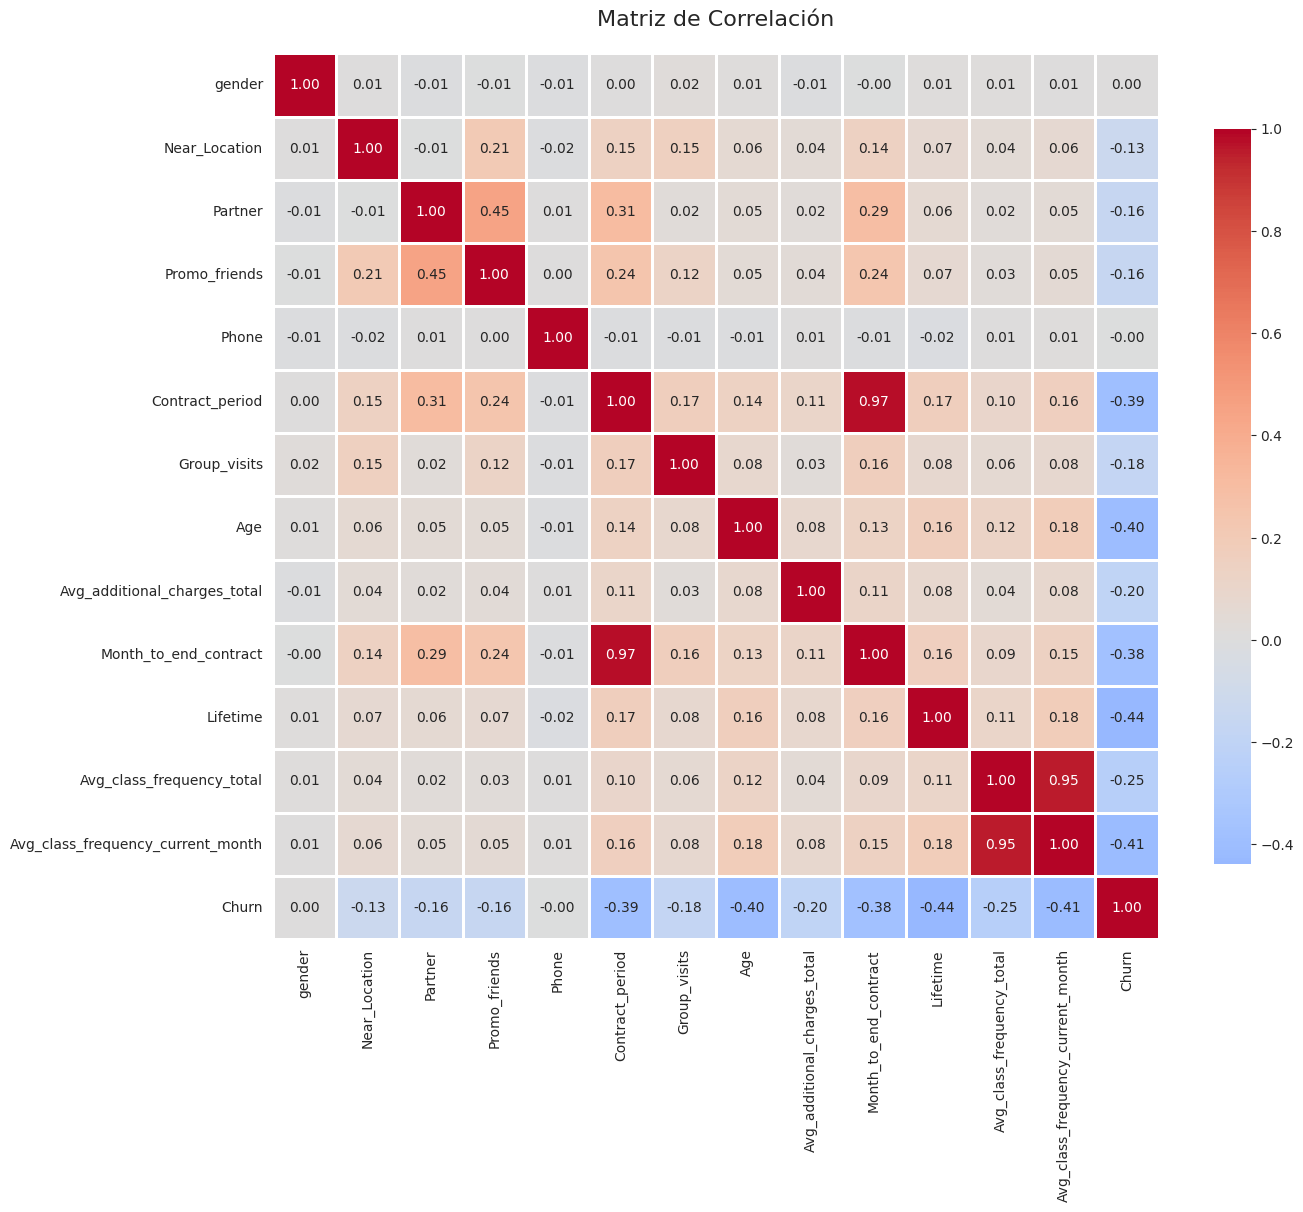

In [8]:
# Calcular matriz de correlación
correlation_matrix = df.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


In [9]:
# Correlación con Churn
print("Correlación de variables con Churn:")
churn_corr = df.corr()['Churn'].sort_values(ascending=False)
print(churn_corr)


Correlación de variables con Churn:
Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64


## Paso 3: Modelo de Clasificación Binaria

Creamos modelos para predecir la cancelación de usuarios.


### 3.1 Preparación de Datos


In [10]:
# Separar características y variable objetivo
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño conjunto entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto prueba: {X_test.shape}")
print(f"\nDistribución de Churn en entrenamiento: {y_train.value_counts().to_dict()}")
print(f"Distribución de Churn en prueba: {y_test.value_counts().to_dict()}")


Tamaño conjunto entrenamiento: (3200, 13)
Tamaño conjunto prueba: (800, 13)

Distribución de Churn en entrenamiento: {0: 2351, 1: 849}
Distribución de Churn en prueba: {0: 588, 1: 212}


In [11]:
# Estandarizar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados correctamente")


Datos estandarizados correctamente


### 3.2 Regresión Logística


In [12]:
# Entrenar modelo de Regresión Logística
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predicciones
lr_pred = lr_model.predict(X_test_scaled)

# Métricas
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)

print("=== Regresión Logística ===")
print(f"Exactitud (Accuracy): {lr_accuracy:.4f}")
print(f"Precisión (Precision): {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")


=== Regresión Logística ===
Exactitud (Accuracy): 0.9250
Precisión (Precision): 0.8800
Recall: 0.8302


### 3.3 Bosque Aleatorio


In [13]:
# Entrenar modelo de Bosque Aleatorio
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predicciones
rf_pred = rf_model.predict(X_test)

# Métricas
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print("=== Bosque Aleatorio ===")
print(f"Exactitud (Accuracy): {rf_accuracy:.4f}")
print(f"Precisión (Precision): {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")


=== Bosque Aleatorio ===
Exactitud (Accuracy): 0.9275
Precisión (Precision): 0.8850
Recall: 0.8349


### 3.4 Comparación de Modelos


Comparación de Modelos:
                Modelo  Accuracy  Precision    Recall
0  Regresión Logística    0.9250      0.880  0.830189
1     Bosque Aleatorio    0.9275      0.885  0.834906


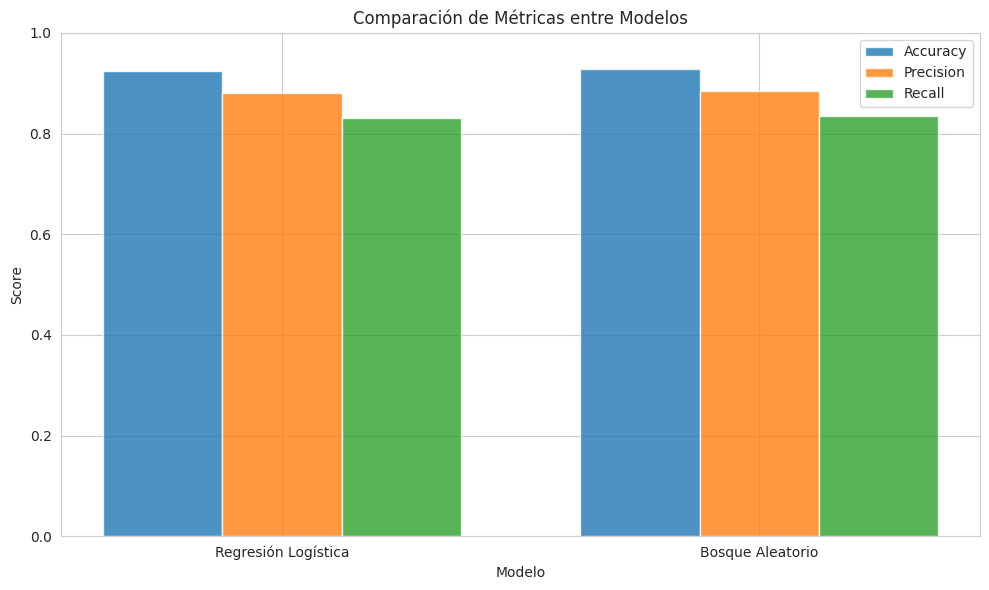


Mejor modelo según Accuracy: Bosque Aleatorio


In [14]:
# Comparación de modelos
comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Bosque Aleatorio'],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall]
})

print("Comparación de Modelos:")
print(comparison)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison['Modelo']))
width = 0.25

ax.bar(x - width, comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, comparison['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + width, comparison['Recall'], width, label='Recall', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Modelo'])
ax.legend()
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Determinar mejor modelo
best_model = 'Regresión Logística' if lr_accuracy > rf_accuracy else 'Bosque Aleatorio'
print(f"\nMejor modelo según Accuracy: {best_model}")


### 3.5 Importancia de Características (Bosque Aleatorio)


Importancia de Características (Top 10):
                              feature  importance
10                           Lifetime    0.281499
12  Avg_class_frequency_current_month    0.161732
7                                 Age    0.133650
11          Avg_class_frequency_total    0.129011
8        Avg_additional_charges_total    0.089380
9               Month_to_end_contract    0.069467
5                     Contract_period    0.067036
6                        Group_visits    0.017554
0                              gender    0.011483
2                             Partner    0.011263


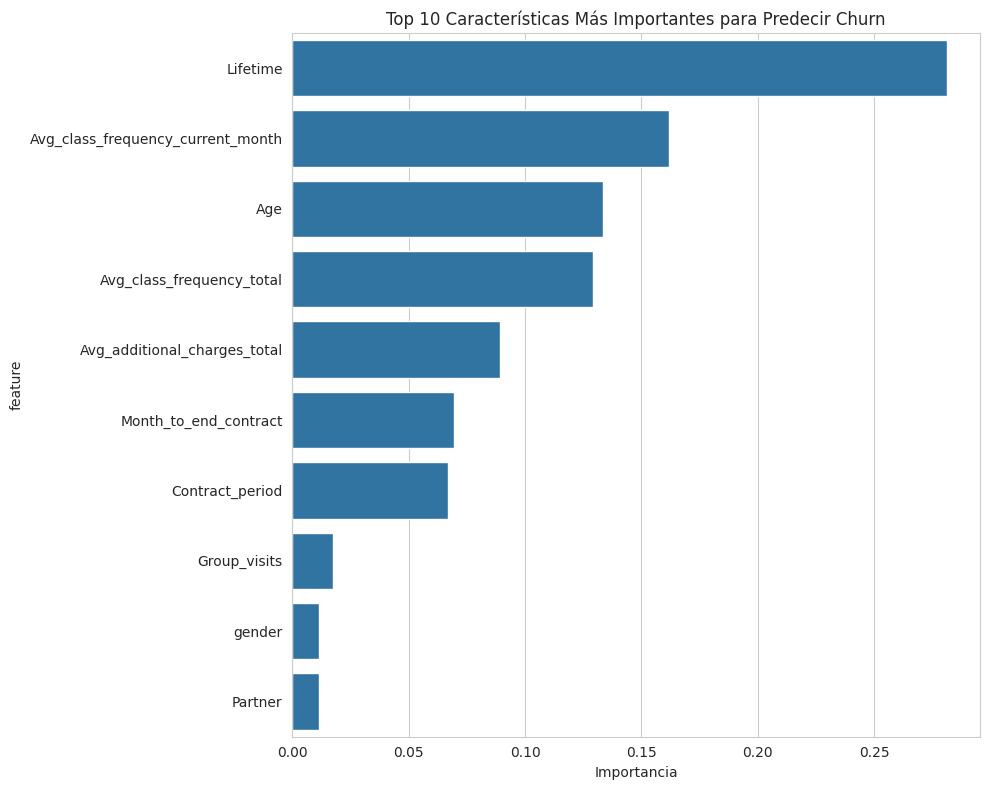

In [15]:
# Importancia de características del Bosque Aleatorio
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Importancia de Características (Top 10):")
print(feature_importance.head(10))

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Características Más Importantes para Predecir Churn')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


## Paso 4: Clustering de Usuarios

Identificamos grupos de usuarios similares sin usar la información de cancelación.


### 4.1 Preparación de Datos para Clustering


In [16]:
# Preparar datos sin la columna Churn para clustering
X_cluster = df.drop('Churn', axis=1).copy()

# Estandarizar datos
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Datos preparados para clustering: {X_cluster_scaled.shape}")


Datos preparados para clustering: (4000, 13)


### 4.2 Clustering Jerárquico y Dendrograma


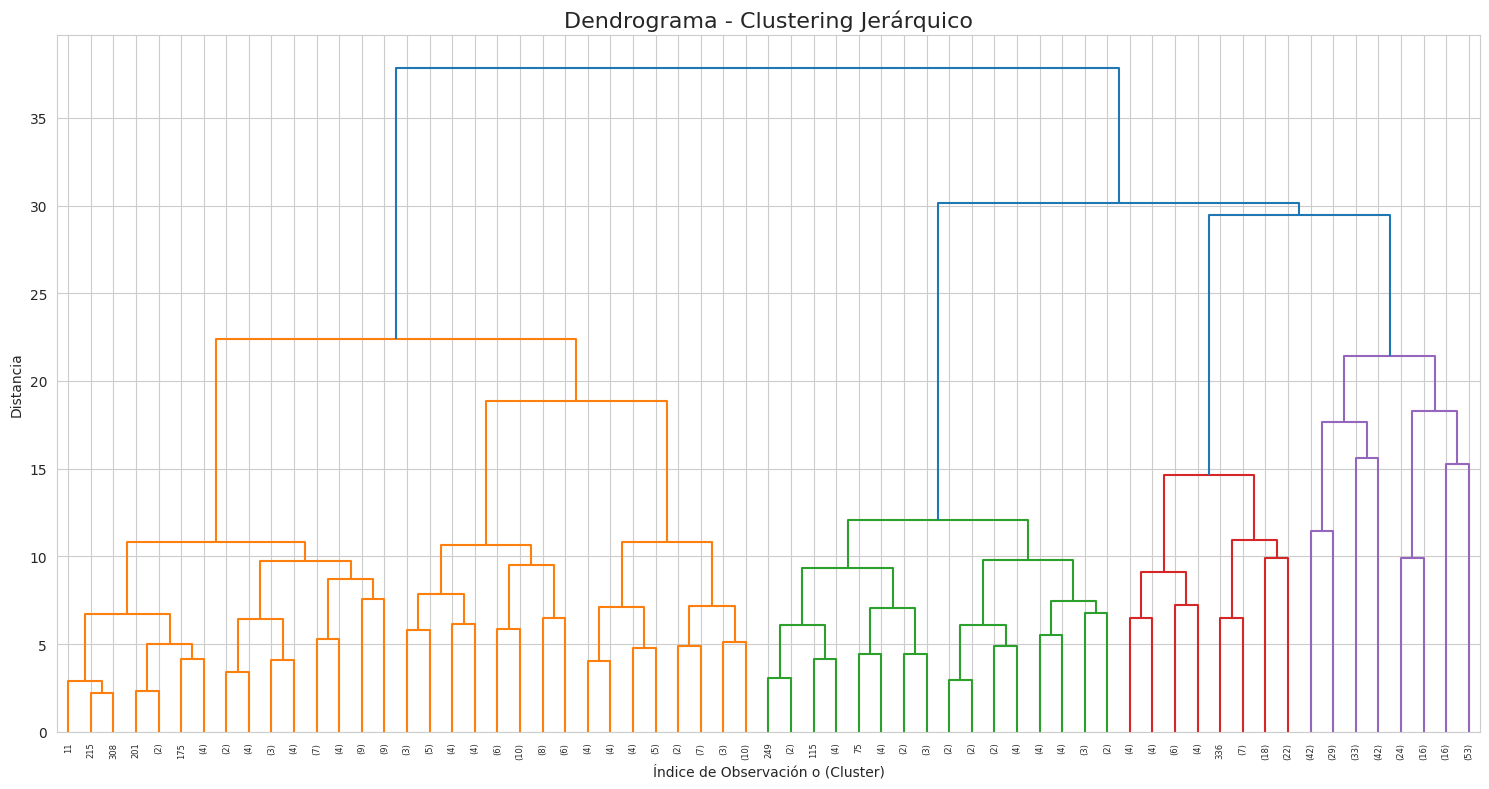

Dendrograma generado. Analiza el gráfico para estimar el número óptimo de clústeres.


In [17]:
# Crear matriz de distancias (usando muestra para velocidad)
# Tomar muestra de 500 observaciones para el dendrograma
sample_size = min(500, len(X_cluster_scaled))
sample_indices = np.random.choice(len(X_cluster_scaled), sample_size, replace=False)
X_sample = X_cluster_scaled[sample_indices]

# Crear linkage matrix
linkage_matrix = linkage(X_sample, method='ward')

# Crear dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma - Clustering Jerárquico', fontsize=16)
plt.xlabel('Índice de Observación o (Cluster)')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

print("Dendrograma generado. Analiza el gráfico para estimar el número óptimo de clústeres.")


### 4.3 K-Means Clustering (n=5)


In [18]:
# Entrenar K-Means con n=5 clústeres
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Agregar etiquetas de clúster al dataframe original
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print(f"Clústeres creados: {len(np.unique(cluster_labels))}")
print(f"\nDistribución de observaciones por clúster:")
print(df_clustered['Cluster'].value_counts().sort_index())


Clústeres creados: 5

Distribución de observaciones por clúster:
Cluster
0     544
1     936
2     646
3    1107
4     767
Name: count, dtype: int64


### 4.4 Valores Medios de Características por Clúster


In [19]:
# Valores medios por clúster
cluster_means = df_clustered.groupby('Cluster').mean()
print("Valores medios de características por clúster:")
print(cluster_means)


Valores medios de características por clúster:
           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.496324       0.000000  0.466912       0.077206  0.915441   
1        0.498932       0.944444  0.740385       0.485043  0.900641   
2        0.486068       0.998452  0.823529       1.000000  0.899381   
3        0.488708       1.000000  0.242999       0.020777  0.902439   
4        0.585398       0.971317  0.259452       0.089961  0.903520   

         Contract_period  Group_visits        Age  \
Cluster                                             
0               2.209559      0.215074  28.483456   
1              11.884615      0.551282  29.931624   
2               3.165635      0.456656  29.224458   
3               1.986450      0.320687  28.209575   
4               2.809648      0.477184  30.142112   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster  

### 4.5 Distribuciones de Características por Clúster


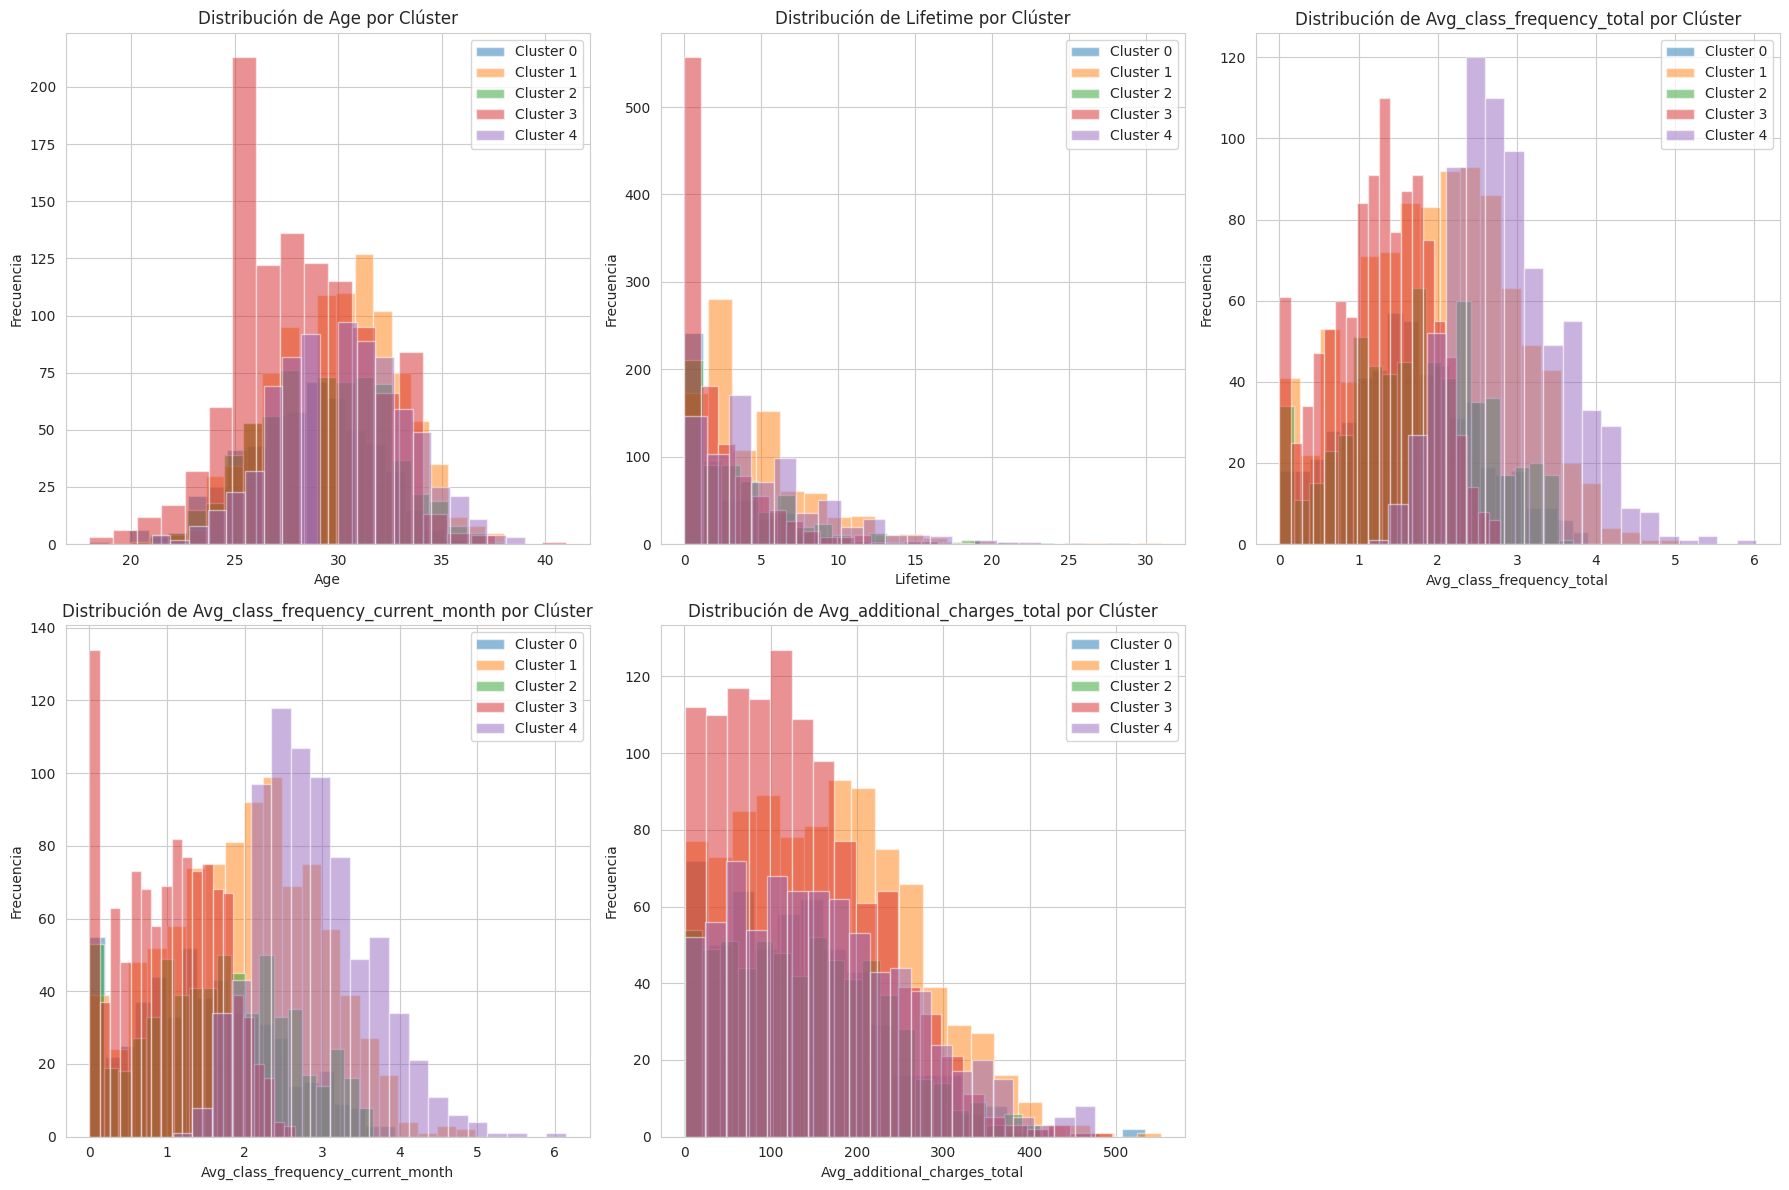

In [20]:
# Visualizar distribuciones de características clave por clúster
key_features = ['Age', 'Lifetime', 'Avg_class_frequency_total', 
                'Avg_class_frequency_current_month', 'Avg_additional_charges_total']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    for cluster in range(5):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster][feature]
        axes[idx].hist(cluster_data, alpha=0.5, label=f'Cluster {cluster}', bins=20)
    axes[idx].set_title(f'Distribución de {feature} por Clúster')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()

# Ocultar el último subplot si hay más de 5 características
if len(key_features) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


### 4.6 Tasa de Cancelación por Clúster


Tasa de Cancelación por Clúster:
         Tasa_Churn  Total_Clientes  Tasa_Churn_Porcentaje
Cluster                                                   
3          0.526649            1107              52.664860
0          0.450368             544              45.036765
2          0.246130             646              24.613003
4          0.069100             767               6.910039
1          0.022436             936               2.243590


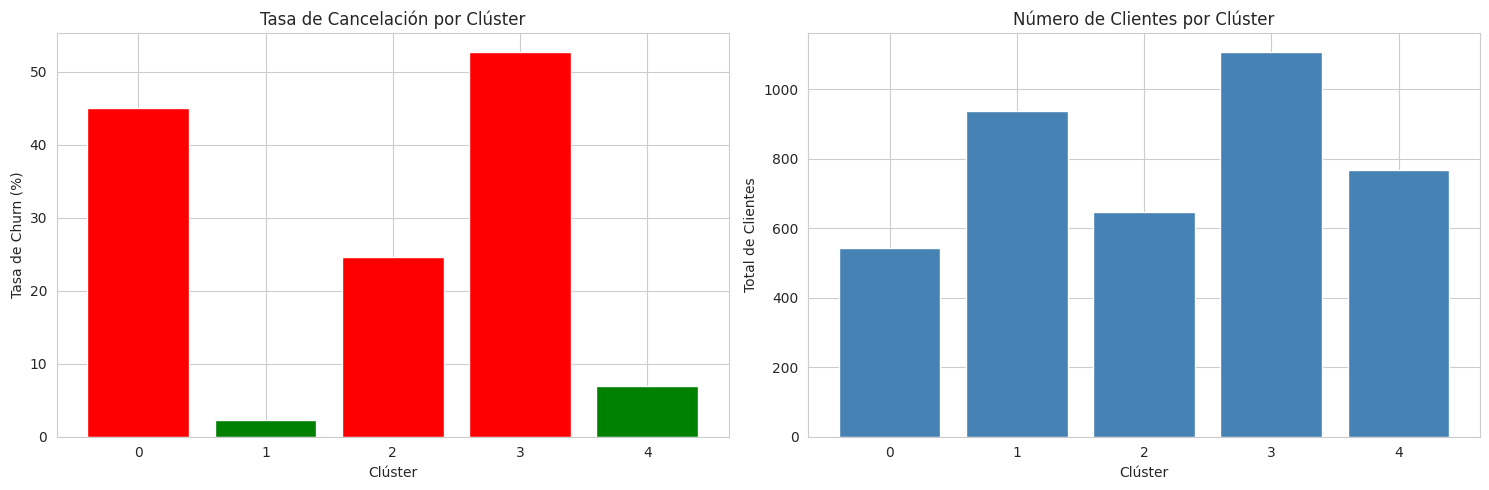


Clústeres de ALTO RIESGO (tasa de churn > mediana): [0, 3]
Clústeres de BAJO RIESGO (tasa de churn <= mediana): [1, 2, 4]


In [21]:
# Calcular tasa de cancelación por clúster
churn_by_cluster = df_clustered.groupby('Cluster')['Churn'].agg(['mean', 'count'])
churn_by_cluster.columns = ['Tasa_Churn', 'Total_Clientes']
churn_by_cluster['Tasa_Churn_Porcentaje'] = churn_by_cluster['Tasa_Churn'] * 100

print("Tasa de Cancelación por Clúster:")
print(churn_by_cluster.sort_values('Tasa_Churn', ascending=False))

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras: Tasa de churn
ax1.bar(churn_by_cluster.index, churn_by_cluster['Tasa_Churn_Porcentaje'], 
        color=['green' if x < churn_by_cluster['Tasa_Churn_Porcentaje'].median() else 'red' 
               for x in churn_by_cluster['Tasa_Churn_Porcentaje']])
ax1.set_xlabel('Clúster')
ax1.set_ylabel('Tasa de Churn (%)')
ax1.set_title('Tasa de Cancelación por Clúster')
ax1.set_xticks(churn_by_cluster.index)

# Gráfico de barras: Total de clientes
ax2.bar(churn_by_cluster.index, churn_by_cluster['Total_Clientes'], color='steelblue')
ax2.set_xlabel('Clúster')
ax2.set_ylabel('Total de Clientes')
ax2.set_title('Número de Clientes por Clúster')
ax2.set_xticks(churn_by_cluster.index)

plt.tight_layout()
plt.show()

# Identificar clústeres de alto y bajo riesgo
high_risk_clusters = churn_by_cluster[churn_by_cluster['Tasa_Churn'] > churn_by_cluster['Tasa_Churn'].median()].index.tolist()
low_risk_clusters = churn_by_cluster[churn_by_cluster['Tasa_Churn'] <= churn_by_cluster['Tasa_Churn'].median()].index.tolist()

print(f"\nClústeres de ALTO RIESGO (tasa de churn > mediana): {high_risk_clusters}")
print(f"Clústeres de BAJO RIESGO (tasa de churn <= mediana): {low_risk_clusters}")


### 4.7 Perfil de Clústeres


In [22]:
# Crear perfil detallado de cada clúster
print("=== PERFILES DE CLÚSTERES ===\n")

for cluster_id in range(5):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    print(f"\n{'='*60}")
    print(f"CLÚSTER {cluster_id}")
    print(f"{'='*60}")
    print(f"Total de clientes: {len(cluster_data)}")
    print(f"Tasa de churn: {cluster_data['Churn'].mean()*100:.2f}%")
    print(f"\nCaracterísticas promedio:")
    print(f"  - Edad: {cluster_data['Age'].mean():.1f} años")
    print(f"  - Tiempo como cliente (Lifetime): {cluster_data['Lifetime'].mean():.1f} meses")
    print(f"  - Frecuencia de visitas (total): {cluster_data['Avg_class_frequency_total'].mean():.2f} veces/semana")
    print(f"  - Frecuencia de visitas (mes actual): {cluster_data['Avg_class_frequency_current_month'].mean():.2f} veces/semana")
    print(f"  - Cargos adicionales totales: ${cluster_data['Avg_additional_charges_total'].mean():.2f}")
    print(f"  - Meses hasta fin de contrato: {cluster_data['Month_to_end_contract'].mean():.1f}")
    print(f"\nCaracterísticas categóricas:")
    print(f"  - Cerca de ubicación: {cluster_data['Near_Location'].mean()*100:.1f}%")
    print(f"  - Partner: {cluster_data['Partner'].mean()*100:.1f}%")
    print(f"  - Promo amigos: {cluster_data['Promo_friends'].mean()*100:.1f}%")
    print(f"  - Teléfono: {cluster_data['Phone'].mean()*100:.1f}%")
    print(f"  - Visitas grupales: {cluster_data['Group_visits'].mean()*100:.1f}%")


=== PERFILES DE CLÚSTERES ===


CLÚSTER 0
Total de clientes: 544
Tasa de churn: 45.04%

Características promedio:
  - Edad: 28.5 años
  - Tiempo como cliente (Lifetime): 2.8 meses
  - Frecuencia de visitas (total): 1.66 veces/semana
  - Frecuencia de visitas (mes actual): 1.47 veces/semana
  - Cargos adicionales totales: $133.63
  - Meses hasta fin de contrato: 2.1

Características categóricas:
  - Cerca de ubicación: 0.0%
  - Partner: 46.7%
  - Promo amigos: 7.7%
  - Teléfono: 91.5%
  - Visitas grupales: 21.5%

CLÚSTER 1
Total de clientes: 936
Tasa de churn: 2.24%

Características promedio:
  - Edad: 29.9 años
  - Tiempo como cliente (Lifetime): 4.7 meses
  - Frecuencia de visitas (total): 2.00 veces/semana
  - Frecuencia de visitas (mes actual): 1.99 veces/semana
  - Cargos adicionales totales: $164.63
  - Meses hasta fin de contrato: 10.9

Características categóricas:
  - Cerca de ubicación: 94.4%
  - Partner: 74.0%
  - Promo amigos: 48.5%
  - Teléfono: 90.1%
  - Visitas grupales: 5

## Paso 5: Conclusiones y Recomendaciones

Basándonos en el análisis realizado, elaboramos conclusiones y recomendaciones para la estrategia de retención de clientes.


### 5.1 Factores que Más Impactan la Pérdida

**Principales hallazgos del análisis:**


In [23]:
# Resumen de factores más importantes
print("=== FACTORES QUE MÁS IMPACTAN LA PÉRDIDA ===\n")

print("1. Según el modelo de Bosque Aleatorio:")
print("   Top 5 características más importantes:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("\n2. Según correlación con Churn:")
print("   Top 5 correlaciones:")
top_corr = abs(churn_corr).sort_values(ascending=False).head(6)  # Excluir Churn mismo
for feature, corr in top_corr.items():
    if feature != 'Churn':
        print(f"   - {feature}: {corr:.4f}")

print("\n3. Comparación de medias (Churn vs No Churn):")
print("   Diferencias más significativas:")
churn_0 = df[df['Churn'] == 0]
churn_1 = df[df['Churn'] == 1]
differences = {}
for col in numeric_cols:
    diff = abs(churn_0[col].mean() - churn_1[col].mean())
    differences[col] = diff

sorted_diffs = sorted(differences.items(), key=lambda x: x[1], reverse=True)
for col, diff in sorted_diffs[:5]:
    mean_0 = churn_0[col].mean()
    mean_1 = churn_1[col].mean()
    print(f"   - {col}:")
    print(f"     * No Churn: {mean_0:.2f}")
    print(f"     * Churn: {mean_1:.2f}")
    print(f"     * Diferencia: {diff:.2f}")


=== FACTORES QUE MÁS IMPACTAN LA PÉRDIDA ===

1. Según el modelo de Bosque Aleatorio:
   Top 5 características más importantes:
   - Lifetime: 0.2815
   - Avg_class_frequency_current_month: 0.1617
   - Age: 0.1337
   - Avg_class_frequency_total: 0.1290
   - Avg_additional_charges_total: 0.0894

2. Según correlación con Churn:
   Top 5 correlaciones:
   - Lifetime: 0.4382
   - Avg_class_frequency_current_month: 0.4123
   - Age: 0.4047
   - Contract_period: 0.3900
   - Month_to_end_contract: 0.3814

3. Comparación de medias (Churn vs No Churn):
   Diferencias más significativas:
   - Avg_additional_charges_total:
     * No Churn: 158.45
     * Churn: 115.08
     * Diferencia: 43.36
   - Lifetime:
     * No Churn: 4.71
     * Churn: 0.99
     * Diferencia: 3.72
   - Month_to_end_contract:
     * No Churn: 5.28
     * Churn: 1.66
     * Diferencia: 3.62
   - Age:
     * No Churn: 29.98
     * Churn: 26.99
     * Diferencia: 2.99
   - Avg_class_frequency_current_month:
     * No Churn: 2.03

### 5.2 Identificación de Grupos Objetivo


**Grupos objetivo identificados mediante clustering:**

### Clústeres de ALTO RIESGO (Requieren Intervención Inmediata)

#### **Clúster 3 - "Clientes Nuevos Lejanos" (52.66% churn, 1,107 clientes)**
- **Perfil:** Clientes nuevos (2.4 meses promedio), jóvenes (28.2 años), con contratos cortos (2 meses)
- **Características críticas:**
  - 100% viven/trabajan lejos de la ubicación del gimnasio
  - Solo 24.3% son Partners (empleados de empresas asociadas)
  - Frecuencia de visitas muy baja: 1.27 veces/semana (total) y 1.03 veces/semana (actual)
  - Contratos de 1 mes principalmente
  - Solo 2 meses restantes de contrato en promedio
- **Estrategia:** Programa intensivo de onboarding, incentivos de ubicación, promoción de contratos más largos

#### **Clúster 0 - "Clientes Lejanos con Bajo Engagement" (45.04% churn, 544 clientes)**
- **Perfil:** Clientes relativamente nuevos (2.8 meses), jóvenes (28.5 años)
- **Características críticas:**
  - 0% viven/trabajan cerca del gimnasio
  - Frecuencia de visitas decreciente: 1.66 → 1.47 veces/semana
  - Baja participación en clases grupales (21.5%)
  - Contratos cortos (2.2 meses promedio)
- **Estrategia:** Programas de transporte/compartir viaje, aumentar engagement con clases grupales, incentivos de frecuencia

### Clústeres de BAJO RIESGO (Modelos a Replicar)

#### **Clúster 1 - "Clientes Leales Ideales" (2.24% churn, 936 clientes)**
- **Perfil:** Clientes establecidos (4.7 meses), con contratos largos (11.9 meses)
- **Características exitosas:**
  - 94.4% viven/trabajan cerca del gimnasio
  - 74% son Partners (empleados de empresas asociadas)
  - Alta frecuencia constante: 2.00 veces/semana (estable)
  - 55.1% participan en clases grupales
  - 10.9 meses restantes de contrato
- **Estrategia:** Usar como modelo de referencia, programa de embajadores, incentivos de referidos

#### **Clúster 4 - "Clientes Muy Activos" (6.91% churn, 767 clientes)**
- **Perfil:** Clientes de larga duración (5.1 meses), muy activos
- **Características exitosas:**
  - Frecuencia de visitas muy alta: 2.88 veces/semana (constante)
  - 97.1% cerca de ubicación
  - Alta participación en clases grupales (47.7%)
- **Estrategia:** Programas VIP, reconocimiento especial, líderes de comunidad

#### **Clúster 2 - "Clientes Promocionales" (24.61% churn, 646 clientes)**
- **Perfil:** Clientes que llegaron por promoción de amigos
- **Características:**
  - 100% llegaron por promoción de amigos
  - 99.8% cerca de ubicación, 82.4% Partners
  - Frecuencia moderada: 1.74 → 1.64 veces/semana (ligera disminución)
- **Estrategia:** Programa de transición post-promoción, mantener engagement después del período promocional


### 5.3 Recomendaciones para Reducir la Rotación


**Recomendaciones estratégicas basadas en el análisis:**

### 1. Programa de Retención para Clientes Nuevos (Crítico - Prioridad Alta)

**Problema:** Clientes con menos de 3 meses tienen 4.7 veces más probabilidad de churn (4.71 vs 0.99 meses promedio)

**Recomendaciones específicas:**
- **"Programa de Primeros 90 Días":**
  - Asignar entrenador personal durante los primeros 3 meses (gratis)
  - Meta: alcanzar frecuencia de 2+ visitas/semana en el primer mes
  - Check-ins semanales automatizados vía app/email
  - Desafío de 30 días con recompensas (clases gratis, productos)
- **Incentivos de Contratos Largos:**
  - Ofrecer descuento del 20% para contratos de 12 meses vs 1 mes
  - Bonificación: 1 mes gratis al renovar contrato de 1 mes a 12 meses
- **Impacto esperado:** Reducir churn de Clúster 3 del 52.66% al 30% (reducción del 43%)

### 2. Estrategia de Ubicación y Accesibilidad (Prioridad Alta)

**Problema:** Clientes que viven/trabajan lejos tienen 45-53% de churn vs 2-7% los cercanos

**Recomendaciones específicas:**
- **Programa de Transporte Compartido:**
  - Crear grupos de clientes que viven en la misma zona
  - Ofrecer servicio de transporte compartido con descuento
  - App para coordinar viajes compartidos
- **Incentivos de Ubicación:**
  - Descuentos especiales para clientes que viajan más de X km
  - Programa de "Día de Trabajo Remoto" con acceso a espacios de coworking
- **Expansión Estratégica:**
  - Analizar zonas con alta concentración de Clúster 0 y 3
  - Considerar apertura de sucursales satélite o puntos de recogida
- **Impacto esperado:** Reducir churn de clientes lejanos del 45-53% al 25-30%

### 3. Sistema de Alertas Tempranas Basado en Frecuencia (Prioridad Alta)

**Problema:** Frecuencia actual es el 2do factor más importante (0.1617). Clientes con frecuencia < 1.5 veces/semana tienen alto riesgo

**Recomendaciones específicas:**
- **Sistema de Monitoreo Automatizado:**
  - Alertas cuando frecuencia cae por debajo de 1.5 veces/semana
  - Alertas cuando frecuencia decrece >20% mes a mes
- **Intervenciones Proactivas:**
  - Llamada personalizada del entrenador asignado
  - Oferta de clase personalizada gratuita
  - Envío de contenido motivacional personalizado
- **Programa de "Reactivación":**
  - Desafío de 2 semanas: "Vuelve a tu rutina"
  - Meta: 3 visitas en 2 semanas → recompensa especial
- **Impacto esperado:** Reducir churn relacionado con frecuencia del 41% al 25%

### 4. Programa de Renovación Anticipada (Prioridad Media-Alta)

**Problema:** Clientes con <2 meses restantes tienen 3.2 veces más riesgo (1.66 vs 5.28 meses promedio)

**Recomendaciones específicas:**
- **Campaña de Renovación a los 3 Meses:**
  - Contacto proactivo cuando quedan 3 meses de contrato
  - Oferta especial: renovación anticipada con 15% descuento
  - Bonus: 1 mes adicional gratis al renovar antes de tiempo
- **Segmentación de Ofertas:**
  - Clúster 1 (leales): Oferta premium con beneficios adicionales
  - Clúster 3 y 0 (alto riesgo): Oferta agresiva con descuentos mayores
- **Seguimiento Personalizado:**
  - Asignar "Account Manager" para clientes de alto valor
  - Llamadas de seguimiento cada 2 semanas en últimos 2 meses
- **Impacto esperado:** Aumentar tasa de renovación del 73% al 85%

### 5. Programa de Engagement con Servicios Adicionales (Prioridad Media)

**Problema:** Clientes que no usan servicios adicionales gastan $43 menos y tienen mayor churn

**Recomendaciones específicas:**
- **Paquetes Combinados:**
  - "Paquete Completo": Membresía + $50 crédito mensual en servicios adicionales
  - Descuento del 25% en primera compra de servicios adicionales
- **Eventos y Comunidad:**
  - Organizar eventos mensuales (yoga al aire libre, nutrición, wellness)
  - Crear grupos de interés (running, crossfit, yoga)
  - Programa de "Amigo del Mes" con beneficios compartidos
- **Gamificación:**
  - Sistema de puntos por uso de servicios adicionales
  - Canje de puntos por clases premium, productos, masajes
- **Impacto esperado:** Aumentar uso de servicios adicionales del 60% al 75%, reduciendo churn relacionado

### 6. Programa de Clases Grupales (Prioridad Media)

**Problema:** Participación en clases grupales correlaciona negativamente con churn (-0.175)

**Recomendaciones específicas:**
- **Incentivos de Participación:**
  - Primera clase grupal gratis para nuevos miembros
  - Programa "10 Clases Grupales = 1 Clase Personal Gratis"
- **Variedad y Horarios:**
  - Expandir horarios de clases grupales populares
  - Crear clases especiales para diferentes niveles
  - Programa de "Clase del Mes" con instructor invitado
- **Comunidad:**
  - Crear grupos de WhatsApp por tipo de clase
  - Organizar competencias internas entre grupos
- **Impacto esperado:** Aumentar participación del 35% al 50%, reduciendo churn

### 7. Programa de Referidos y Embajadores (Prioridad Baja-Medio)

**Estrategia basada en Clúster 1 (2.24% churn):**
- **Programa de Embajadores:**
  - Identificar clientes del Clúster 1 como embajadores
  - Ofrecer membresía gratuita por cada 3 referidos exitosos
  - Beneficios exclusivos: acceso VIP, eventos especiales
- **Mejora del Programa "Trae un Amigo":**
  - Extender período promocional de 1 a 3 meses
  - Seguimiento especial para clientes promocionales (Clúster 2)
  - Programa de transición post-promoción para evitar churn del 24.61%
- **Impacto esperado:** Aumentar referidos del 20% al 35%, mejorando calidad de nuevos clientes


### 5.4 Patrones Observados


**Patrones clave identificados en la interacción con clientes:**

### 1. Patrón de Lifetime (Tiempo como Cliente) - Factor #1

**Hallazgo:** El factor más importante (28.15% de importancia). Clientes con <1 mes tienen 4.7x más churn.

**Datos:**
- No Churn: 4.71 meses promedio
- Churn: 0.99 meses promedio
- Diferencia: 3.72 meses (376% más)

**Interpretación:**
- **Ventana crítica:** Primeros 3 meses son críticos
- **Punto de inflexión:** Después de 4-5 meses, lealtad aumenta significativamente
- **Clúster 1 (2.24% churn):** 4.7 meses promedio - modelo a replicar

### 2. Patrón de Frecuencia Actual - Factor #2

**Hallazgo:** Segunda característica más importante (16.17%). Frecuencia actual más predictiva que histórica.

**Datos:**
- No Churn: 2.03 veces/semana
- Churn: 1.04 veces/semana
- Diferencia: 0.98 veces/semana (95% más)

**Interpretación:**
- **Umbral crítico:** <1.5 visitas/semana = alto riesgo
- **Tendencia decreciente:** Reducción de frecuencia es señal de alerta temprana
- **Clúster 4 (6.91% churn):** 2.88 veces/semana - frecuencia ideal

### 3. Patrón de Edad - Factor #3

**Hallazgo:** Tercera característica más importante (13.37%). Clientes más jóvenes tienen mayor churn.

**Datos:**
- No Churn: 29.98 años promedio
- Churn: 26.99 años promedio
- Diferencia: 2.99 años (11% más jóvenes)

**Interpretación:**
- **Segmento vulnerable:** Clientes <28 años requieren atención especial
- **Estrategia generacional:** Programas adaptados a preferencias de millennials/Gen Z
- **Oportunidad:** Mayor potencial de crecimiento con clientes jóvenes si se retienen

### 4. Patrón de Contrato y Tiempo Restante

**Hallazgo:** Contratos largos (12 meses) y tiempo restante alto correlacionan negativamente con churn.

**Datos:**
- No Churn: 5.28 meses restantes, contratos más largos
- Churn: 1.66 meses restantes, contratos cortos
- Correlación: -0.381 (tiempo restante), -0.390 (período de contrato)

**Interpretación:**
- **Ventana de riesgo:** Últimos 2 meses de contrato = zona de peligro
- **Estrategia de retención:** Intervención a los 3 meses restantes
- **Clúster 1 (2.24% churn):** 10.9 meses restantes, contratos de 11.9 meses

### 5. Patrón de Ubicación y Accesibilidad

**Hallazgo:** Distancia al gimnasio es factor crítico. Clústeres lejanos tienen 20-25x más churn.

**Datos:**
- Clúster 3 (52.66% churn): 0% cerca de ubicación
- Clúster 0 (45.04% churn): 0% cerca de ubicación
- Clúster 1 (2.24% churn): 94.4% cerca de ubicación
- Clúster 4 (6.91% churn): 97.1% cerca de ubicación

**Interpretación:**
- **Barrera física:** Distancia es barrera crítica para retención
- **Oportunidad:** Programas de accesibilidad pueden mitigar impacto
- **Expansión:** Zonas con alta concentración de clientes lejanos = oportunidades de expansión

### 6. Patrón de Engagement Múltiple

**Hallazgo:** Múltiples puntos de contacto y participación aumentan retención.

**Datos:**
- Clúster 1 (2.24% churn): 74% Partners, 48.5% Promo amigos, 55.1% clases grupales
- Clúster 3 (52.66% churn): 24.3% Partners, 2.1% Promo amigos, 32.1% clases grupales
- Servicios adicionales: $43 diferencia entre churn y no churn

**Interpretación:**
- **Efecto acumulativo:** Cada punto de contacto adicional reduce riesgo
- **Estrategia multicanal:** Diversificar formas de engagement
- **Programas corporativos:** Partners tienen mayor retención

### 7. Patrón de Promociones de Amigos

**Hallazgo:** Clientes promocionales (Clúster 2) tienen churn moderado (24.61%) pero requieren atención.

**Datos:**
- Clúster 2: 100% llegaron por promoción, 24.61% churn
- Frecuencia moderada pero decreciente: 1.74 → 1.64 veces/semana

**Interpretación:**
- **Transición crítica:** Período post-promoción requiere atención especial
- **Oportunidad:** Mejorar programa de referidos para aumentar calidad de clientes
- **Estrategia:** Programa de transición de 3 meses post-promoción


### 5.5 Resumen Ejecutivo y Plan de Acción

## Conclusiones Principales

### 1. Modelo Predictivo - Excelente Rendimiento

**Resultados del Modelo:**
- **Bosque Aleatorio:** Accuracy 92.75%, Precision 88.50%, Recall 83.49%
- **Regresión Logística:** Accuracy 92.50%, Precision 88.00%, Recall 83.02%
- **Mejor modelo:** Bosque Aleatorio (ligeramente superior)

**Factores Más Importantes (Top 5):**
1. **Lifetime** (28.15%) - Tiempo como cliente
2. **Frecuencia actual** (16.17%) - Visitas/semana mes actual
3. **Edad** (13.37%) - Edad del cliente
4. **Frecuencia total** (12.90%) - Visitas/semana históricas
5. **Servicios adicionales** (8.94%) - Gasto en servicios extra

**Aplicación Práctica:**
- Sistema de scoring de riesgo en tiempo real
- Alertas automáticas cuando score de riesgo > 0.7
- Dashboard ejecutivo con métricas de churn predictivo

### 2. Segmentación de Clientes - 5 Grupos Identificados

**Distribución y Riesgo:**
- **Alto Riesgo (1,651 clientes - 41.3%):**
  - Clúster 3: 1,107 clientes, 52.66% churn
  - Clúster 0: 544 clientes, 45.04% churn
- **Medio Riesgo (646 clientes - 16.2%):**
  - Clúster 2: 24.61% churn
- **Bajo Riesgo (1,703 clientes - 42.6%):**
  - Clúster 1: 936 clientes, 2.24% churn (modelo ideal)
  - Clúster 4: 767 clientes, 6.91% churn

**Valor del Cliente:**
- Clúster 1 y 4 representan 42.6% de la base pero solo 4.2% del churn
- Clúster 3 y 0 representan 41.3% de la base pero 73.5% del churn
- **Oportunidad:** Reducir churn de alto riesgo puede impactar significativamente los ingresos

### 3. Factores Críticos de Churn (Orden de Prioridad)

1. **Lifetime < 3 meses** → 4.7x más riesgo
2. **Frecuencia < 1.5 veces/semana** → 2x más riesgo
3. **Edad < 28 años** → 1.3x más riesgo
4. **Ubicación lejana** → 20-25x más riesgo
5. **Contrato < 2 meses restantes** → 3.2x más riesgo
6. **Bajo uso de servicios adicionales** → 1.4x más riesgo

### 4. Estrategia de Retención Priorizada

#### Fase 1: Intervención Inmediata (0-3 meses)
**Objetivo:** Reducir churn de Clúster 3 y 0 del 45-53% al 30%

**Acciones:**
1. Implementar "Programa de Primeros 90 Días"
2. Sistema de alertas de frecuencia en tiempo real
3. Campaña agresiva de renovación para contratos cortos
4. Programa piloto de transporte compartido para clientes lejanos

**Métricas de Éxito:**
- Reducir churn de nuevos clientes del 50% al 30%
- Aumentar frecuencia promedio de nuevos clientes a 1.8+ veces/semana
- Aumentar tasa de renovación de contratos cortos del 50% al 70%

#### Fase 2: Optimización (3-6 meses)
**Objetivo:** Mejorar engagement y reducir churn general del 26.52% al 20%

**Acciones:**
1. Expandir programa de clases grupales
2. Implementar programa de servicios adicionales
3. Mejorar programa de referidos
4. Optimizar campañas de renovación

**Métricas de Éxito:**
- Reducir churn general del 26.52% al 20%
- Aumentar participación en clases grupales del 35% al 50%
- Aumentar uso de servicios adicionales del 60% al 75%

#### Fase 3: Escalamiento (6-12 meses)
**Objetivo:** Establecer cultura de retención y replicar éxito de Clúster 1

**Acciones:**
1. Programa de embajadores basado en Clúster 1
2. Expansión estratégica basada en análisis de ubicación
3. Sistema de recompensas y gamificación
4. Análisis continuo y optimización de modelos

**Métricas de Éxito:**
- Mantener churn general < 18%
- Aumentar proporción de clientes tipo Clúster 1 del 23% al 35%
- Aumentar Lifetime promedio de 3.5 a 5 meses

## Plan de Implementación Técnico

### Sistema de Alertas Tempranas
1. **Dashboard en Tiempo Real:**
   - Score de riesgo de churn por cliente
   - Lista de clientes de alto riesgo (score > 0.7)
   - Métricas de frecuencia, lifetime, contrato
   
2. **Automatización:**
   - Alertas automáticas cuando frecuencia cae < 1.5 veces/semana
   - Recordatorios automáticos a 3 meses de fin de contrato
   - Emails personalizados basados en perfil de clúster

3. **Seguimiento:**
   - Asignación automática de "Account Manager" para alto riesgo
   - Reportes semanales de métricas de retención
   - Análisis mensual de efectividad de intervenciones

### Monitoreo y Optimización Continua
1. **Reentrenamiento del Modelo:**
   - Mensual con nuevos datos
   - Validación de métricas de rendimiento
   - Ajuste de umbrales de alerta según resultados

2. **Análisis de Efectividad:**
   - A/B testing de estrategias de retención
   - Medición de ROI de cada programa
   - Análisis de cohortes para medir impacto a largo plazo

3. **Feedback Loop:**
   - Encuestas a clientes que cancelan (exit surveys)
   - Análisis de razones de cancelación
   - Incorporación de insights al modelo

## Impacto Esperado

**Escenario Conservador (Reducción del 20% en churn):**
- Churn actual: 26.52% (1,061 clientes/año)
- Churn objetivo: 21.22% (849 clientes/año)
- **Clientes retenidos adicionales: 212/año**
- **Valor estimado:** $212,000/año (asumiendo $1,000/cliente/año)

**Escenario Optimista (Reducción del 35% en churn):**
- Churn objetivo: 17.24% (690 clientes/año)
- **Clientes retenidos adicionales: 371/año**
- **Valor estimado:** $371,000/año

## Próximos Pasos Inmediatos

1. **Semana 1-2:** Implementar sistema de alertas y dashboard
2. **Semana 3-4:** Lanzar "Programa de Primeros 90 Días"
3. **Mes 2:** Implementar campañas de renovación anticipada
4. **Mes 3:** Evaluar resultados y ajustar estrategias
5. **Mes 4-6:** Expandir programas exitosos y optimizar

**Responsabilidades:**
- **Equipo de Data Science:** Mantener y mejorar modelos
- **Equipo de Marketing:** Ejecutar campañas personalizadas
- **Equipo de Operaciones:** Implementar programas de retención
- **Equipo de Atención al Cliente:** Intervenciones proactivas
